### Sammansatta datatyper, `list`, `tuple`, `dict`, `set`.

### Datatypen `dict`, dictionery, uppslagsverk

Listor är en följd av data i en viss ordning, indexerade av naturliga tal.

Ofta är det mer naturligt att kunna referera till data med andra värden, tex textsträngar. En sådan datatyp är `dict`. I en `dict` står inte objekten i en viss ordning. Tänk på en låda med påsar med olika etiketter. Etiketterna, eller nycklarna, kallas *keys* på engelska.

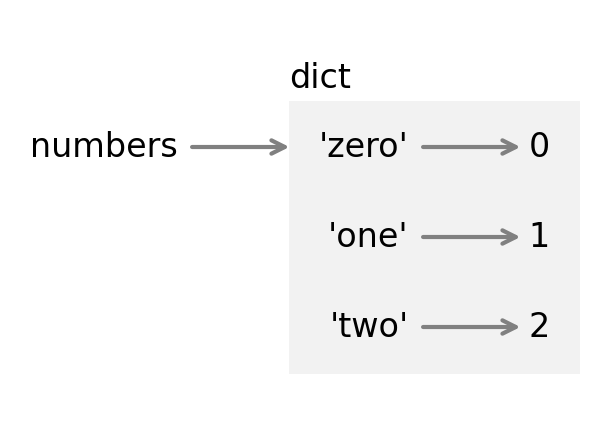

In [ ]:
numbers = {'zero': 0, 'one': 1, 'two': 2} # indexerad med nycklar/etiketter
print(numbers, '\n', numbers['one'], numbers['two'])

{'zero': 0, 'one': 1, 'two': 2} 
 1 2


In [ ]:
annan_dict = {9: 81, 4: 16, 2: 4}
print(annan_dict[4])

16


In [ ]:
annan_dict[12]

KeyError: 12

In [ ]:
k = numbers.keys()
kl = list(k)
print( k, kl, list(k))

dict_keys(['zero', 'one', 'two']) ['zero', 'one', 'two'] ['zero', 'one', 'two']


In [ ]:
v = numbers.values()
print(v, list(v))
print([numbers[key] for key in numbers.keys() ])

dict_values([0, 1, 2]) [0, 1, 2]
[0, 1, 2]


Nycklarna kan vara av olika typ. De måste vara vad som kallas *hashable*, särskilt kan man inte använda listor som nycklar, däremot tupler.

In [ ]:
d1 = {(3,4): 'a'}
d2 = {[3,4]: 'a'}

TypeError: unhashable type: 'list'

In [ ]:
d1[(3,4)]

'a'

#### Hur kan man skapa en `dict`?
En dict kan skrivas in som par av nycklar och värden, med kolon och kommatecken emellan.

`{key0: val0, key1: val1, key2: val2}` (et c).

Liksom listor är dicts också föränderliga (*mutable*), man kan byta ut värden, lägga till och ta bort nyckel/värde-par, etc.

In [ ]:
empty = dict() # skapa en tom dict
ny = dict(empty) # skapa en kopia av empty
ny['noll'] = 0
ny['ett'] = 1
ny['två'] = 2
print(ny, empty)

{'noll': 0, 'ett': 1, 'två': 2} {}


För listor testar `x in lst` om `x` var något av värdena i listan `lst`.

För dicts testar `x in dct` om `x` är någon av nycklarna i dicten `dct` och `x in dct.values()` om `x` är något av värdena.

In [ ]:
'ett' in ny, 1 in ny, 1 in ny.values()

(True, False, True)

#### Läsa en tabell från fil in till dict-data
```
Roll, Förnamn, Efternamn
King Arthur, Graham, Chapman
Sir Lancelot the Brave, John, Cleese
Sir Bors, Terry, Gilliam
Sir Robin the-not-quite-so-brave-as-Sir-Lancelot, Eric, Idle
Sir Bedevere the Wise, Terry, Jones
Sir Galahad the Pure, Michael, Palin
```

I detta exemplet ger första raden vad för slags data som tabelleras,  och följande rader värden. Vi vill skapa en lista av dicts.

Hur representerar vi dessa data lämpligast?

Ett möjligt sätt
+ Vi använder första radens poster som nycklar.
+ Resten av raderna lagras i en `list` där varje rad representeras som en `dict` med nycklar från första raden.

Hur kodar vi detta?

+ En hjälpfunktion som rensar och delar en inläst rad med kommaseparerade fältvärden till en lista.
+ En läsfunktion som givet ett filobjekt läser in filen och skapar dataobjekt.
+ Huvudkoden öppnar filen och anropar läsfunktionen, använder datat.
+ Comprehension kan användas för att skapa listor och dicts.

In [5]:
def split_csv_line(line):
    ''' Delar upp en rad av kommaseparerade fält till en städad lista.'''
    split_list = line.strip().split(',') # rensa ändarna från blankt (whitespace) och dela vid kommatecken
    return [part.strip() for part in split_list] # rensa bort ev. blankt och returnera


def read_my_table(file): # file is a file object
    # läser in första raden och skapar en lista av nycklar.
    keys = split_csv_line(file.readline()) # en lista av nycklar, rensade för whitespace
    # Datavärdena lagras som en lista av dicts
    data_list = [] # Initierar en tom lista
    for line in file: # Fortsätter läsa rad för rad efter de redan lästa raderna
        # Vi plockar ut värdena för de olika fälten
        values = split_csv_line(line)
        if len(values) == len(keys): # Om det är rätt antal fält
            data_list.append( {keys[k]: values[k] for k in range(len(keys)) })
        else: # Om det är fel antal poster
            print(f'Hoppas över: {values}')
    return data_list

# Test
with open('knights.csv', encoding='utf-8') as f:
    knights_list = read_my_table(f)

for post in knights_list:
    print(post)

{'Roll': 'King Arthur', 'Förnamn': 'Graham', 'Efternamn': 'Chapman'}
{'Roll': 'Sir Lancelot the Brave', 'Förnamn': 'John', 'Efternamn': 'Cleese'}
{'Roll': 'Sir Bors', 'Förnamn': 'Terry', 'Efternamn': 'Gilliam'}
{'Roll': 'Sir Robin the-not-quite-so-brave-as-Sir-Lancelot', 'Förnamn': 'Eric', 'Efternamn': 'Idle'}
{'Roll': 'Sir Bedevere the Wise', 'Förnamn': 'Terry', 'Efternamn': 'Jones'}
{'Roll': 'Sir Galahad the Pure', 'Förnamn': 'Michael', 'Efternamn': 'Palin'}


Säg nu att vi vill lista vilken eller vilka roller som spelas av Eric Idle.

In [ ]:
idle_roles  = []
for post in knights_list:
    if post['Förnamn'].lower() == 'eric' and post['Efternamn'].lower() == 'idle':
        idle_roles.append(post['Roll'])
print(idle_roles)

KeyError: 'roll'

#### Läsa dict-data från fil
Antag att en datafil innehåller data på en form där första raderna talar om vad för slags data varje post har och följande rader ger olika värden.

Exempel:
```
ålder, skostorlek, längd, vikt
år, eu, cm, kg
27, 38, 165, 60
32, 43, 185, 94
54, 41, 177, 75
    19, 39, 160, 70
```

I detta exemplet ger första raden vad för slags data som tabelleras, andra raden vilken enhet som används och följande rader mätetal för olika individer.

Hur representerar vi dessa data lämpligast?

Ett möjligt sätt
+ Vi använder första radens poster som nycklar.
+ Vi skapar en `dict` med enheterna kopplade till nycklarna. Läses från andra raden.
+ Resten av raderna lagras i en `list` där varje rad representeras som en `dict` med nycklar från första raden.

Hur kodar vi detta?

+ En hjälpfunktion som rensar och delar en inläst rad med kommaseparerade fältvärden till en lista.
+ En läsfunktion som givet ett filobjekt läser in filen och skapar dataobjekt.
+ Huvudkoden öppnar filen och anropar läsfunktionen, använder datat.
+ Comprehension kan användas för att skapa listor och dicts.

In [ ]:

def split_csv_line(line):
    split_list = line.strip().split(',') # rensa ändarna från blankt (whitespace) och dela vid kommatecken
    return [part.strip() for part in split_list] # rensa bort ev. blankt och returnera

def read_my_table(file): # file is a file object
    # i läser in de första två raderna och skapar en lista av nycklar och en dict med enheter
    keys = split_csv_line(file.readline()) # en lista av nycklar, rensade för whitespace
    units = split_csv_line(file.readline())
    # Vi initierar en tom lista och fyller sedan på poster med 
    # nyckel från keys och värden från units
    units_dict = dict()
    for k in range(len(keys)):
        units_dict[keys[k]] = units[k]
    # Kan också göras kortare och elegantare(?) med dict comprehension:
    # units_dict = {keys[k]: units[k] for k in range(len(keys))}

    # Datavärdena lagras som en lista av dicts
    data_list = [] # Initierar en tom lista
    for line in file: # Fortsätter läsa rad för rad efter de redan lästa raderna
        # Vi plockar ut värdena för de olika fälten
        values = split_csv_line(line)
        if len(values) == len(keys): # Om det är rätt antal fält
            data_list.append( {keys[k]: int(values[k]) for k in range(len(keys)) })
            # Vi antar här att data är av typ int (om float, ta heltalsdelen)
        else: # Om det är fel antal poster
            print(f'Hoppas över: {values}')

    return data_list, units_dict # returnerar ett par (2-tuple)

# test
split_csv_line('  ålder  ,  \t skostorlek,      längd,                  vikt \n')

# test
with open('data1.csv', encoding = 'utf-8') as f:
    data, units = read_my_table(f)
print(f'Fältvariabler: {list(units)}')
print(f'Enheter: {list(units.values())}')
for record in data:
    print(record, f"bmi: {record['vikt']/(record['längd']**2/10000):.1f}") # skriv ut datapost (record)
  


Fältvariabler: ['ålder', 'skostorlek', 'längd', 'vikt']
Enheter: ['år', 'eu', 'cm', 'kg']
{'ålder': 27, 'skostorlek': 38, 'längd': 165, 'vikt': 60} bmi: 22.0
{'ålder': 32, 'skostorlek': 43, 'längd': 185, 'vikt': 94} bmi: 27.5
{'ålder': 54, 'skostorlek': 41, 'längd': 177, 'vikt': 75} bmi: 23.9
{'ålder': 19, 'skostorlek': 39, 'längd': 160, 'vikt': 70} bmi: 27.3


In [ ]:
def corrcoeff(x,y): # Beräknar Pearsons korrelationskoefficient mellan mätserierna x och y
    if len(x) != len(y):
        raise TypeError("Olika långa")
    n = len(x)
    xs, ys = sum(x), sum(y)
    xy = sum(x[i]*y[i] for i in range(n))
    xsqs = sum(xi**2 for xi in x)
    ysqs = sum(yi**2 for yi in y)
    r = (n*xy - xs*ys)/((n*xsqs-xs**2)*(n*ysqs-ys**2))**(1/2)
    return r 

corrcoeff([p['längd'] for p in data], [p['skostorlek'] for p in data])

0.9301118066044222

In [ ]:
import scipy.stats.stats
scipy.stats.stats.pearsonr([p['längd'] for p in data], [p['skostorlek'] for p in data])


C:\Users\kale\AppData\Local\Temp\ipykernel_27240\3365783569.py:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.stats.stats.pearsonr([p['längd'] for p in data], [p['skostorlek'] for p in data])


PearsonRResult(statistic=np.float64(0.9301118066044219), pvalue=np.float64(0.06988819339557795))